<a href="https://colab.research.google.com/github/ohta-ee-ous/Lecture_ImageProcessing/blob/main/%E7%94%BB%E5%83%8F%E5%87%A6%E7%90%86%E6%BC%94%E7%BF%92_4_%E5%B9%BE%E4%BD%95%E5%AD%A6%E7%9A%84%E5%A4%89%E6%8F%9B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
デジタル画像処理演習

#**幾何学的変換**

2026/04/27 改訂

---

この演習では、画像の幾何学的変換に関して次の内容を学習します。
1. 画像の向きとサイズの変更
1. アフィン変換行列
1. 基本的な幾何学的変換
1. 相似変換
1. アフィン変換
1. 内挿
1. 射影変換
1. 合成変換

次に書かれている「準備」から順番に進めていってください。  

最後に[課題](#assignment)があります。

<a name="junbi"></a>
# **準備**

最初に準備を行います。次のコードを実行してください。

In [ ]:
#@title ⌨ 準備
# 外部モジュールを取り込む
import cv2
import numpy as np
from google.colab import output
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

# ユーザーのディスプレイの解像度に合わせて画像の画面表示サイズを調整する
screen_resolution = output.eval_js('[window.screen.width, window.screen.height, screen.orientation.type]')
screen_scale = max(screen_resolution[:2])/1920
def show_image(img):
  if screen_scale >= 1.0:
    cv2_imshow(img)
  else:
    cv2_imshow(cv2.resize(img, None, fx=screen_scale, fy=screen_scale))

# 使用するデータをダウンロードする。
!wget -nc "https://github.com/ohta-ee-ous/Lecture_ImageProcessing/releases/download/v1.0.0/imagefiles.zip" -O imagefiles.zip
!unzip -nq imagefiles.zip
!rm -f imagefiles.zip
!if [[ -f "asagao.png" && -f "README.txt" ]]; then echo "準備が完了しました。"; else echo "ファイルが準備できませんでした。"; fi

「準備が完了しました。」と表示されれば成功です。
次のライブラリや関数が使えるようになっています。

|名称|説明|
|:---|:---|
|cv2|画像処理ライブラリ OpenCV|
|np|数値計算ライブラリ NumPy|
|plt|グラフ描画ライブラリ Matplotlib|
|cv2_imshow|Colab専用の画像表示関数|

画像ファイルも用意されています。Colab の画面の左端にある「ファイル」アイコン（📁の形）をクリックするとファイルブラウザが表示されて、ファイルの一覧を見ることができます。もう一度クリックすると非表示になります。  
自分のパソコンに保存してある画像ファイルを Colab で使いたい場合には、このファイルブラウザの中へ画像ファイルをドラッグ＆ドロップしてください。

<br>

# **1．画像の向きとサイズの変更**

OpenCVで簡単にできる画像の変形として、反転、90度ごとの回転、サイズ変更のやり方を紹介します。

まず、原画像を読み込みます。次のコードを実行してください。

In [ ]:
#@title ⌨ 原画像の読み込み
src = cv2.imread('bird.jpg')
show_image(src)

## 左右反転・上下反転

`cv2.flip`関数を使用すると、画像の左右反転や上下反転が行えます。

<h3>使い方</h3>

*dst* = <tt>cv2.flip</tte>( *src*, *flipCode* )

- *src* : 入力画像の変数を与える。
- *fliCode* : 反転の方向を指定する。
  - <tt>0</tt> : 上下反転
  - <tt>1</tt> : 左右反転
  - <tt>-1</tt> : 上下左右反転（180度回転と同じ）
- *dst* : 出力画像の変数を与える。

画像を左右反転してみます。次のコードを実行してください。

In [ ]:
#@title ⌨ 画像の反転
dst = cv2.flip(src, 1)
show_image(dst)

コードを書き変えて、上下反転や上下左右反転も試してみましょう。

## 90度回転・180度回転

`cv2.rotate`関数を使用すると、画像を90度または180度回転することができます。  
90度回転したときは、画像の縦幅と横幅が入れ替わります。

<h3>使い方</h3>

*dst* = cv2.rotate( *src*, *rotateCode* )

- *src* : 入力画像の変数を与える。
- *rotateCode* : 回転の角度と方向を指定する。
  - <tt>cv2.ROTATE_90_CLOCKWISE</tt> : 時計回りに90度回転
  - <tt>cv2.ROTATE_90_COUNTERCLOCKWISE</tt> : 反時計回りに90度回転
  - <tt>cv2.ROTATE_180</tt> : 180度回転
- *dst* : 出力画像の変数を与える。




画像を時計回りに90度回転してみます。次のコードを実行してください。

In [ ]:
#@title ⌨ 画像の回転
dst = cv2.rotate(src, cv2.ROTATE_90_CLOCKWISE)
show_image(dst)

コードを書き変えて、反時計回りに90度回転や180度回転を試してみましょう。

## サイズ変更

`cv2.resize`関数を使用すると、画像の横幅と縦幅を自由に変更できます。

<h3>使い方</h3>

*dst* = <tt>cv2.resize</tt>( *src*, *dsize*, *dst*, *fx*, *fy*, *interpolation* )

- *src* : 入力画像の変数を与える。
- *dsize* : 変換後のサイズを`(横幅, 縦幅)`で与える。*fx*、*fy*でサイズを指定する場合は`None`を与える。
- *fx* : 横幅の変換倍率を指定する。
- *fy* : 縦幅の変換倍率を指定する。
- *dst* : 出力画像の変数を与える。
- *interpolation* : 内挿法を指定する。（後述）

次のコードは、画像を横幅200画素、縦幅300画素に変換します。

In [ ]:
#@title ⌨ 画像のサイズ変更
dst = cv2.resize(src, (200, 300))
show_image(dst)


<br>

# **2．アフィン変換行列**

アフィン変換は、画像の幾何学的変換の一種です。詳しい説明は後述します。

変換前の座標を $(X,Y)$、変換後の座標を $(x,y)$ とすると、アフィン変換は次式のようになります。

$$\left\{
  \begin{array}{l}
  x = aX+bY+c\\
  y = dX+eY+f
  \end{array}\right.$$

これを行列を使って表すと次のようになります。
$$\begin{pmatrix}x\\y\\1\end{pmatrix}=
 \begin{pmatrix} a&b&c\\d&e&f\\0&0&1\end{pmatrix}
 \begin{pmatrix}X\\Y\\1\end{pmatrix}$$

この行列 $\begin{pmatrix} a&b&c\\d&e&f\\0&0&1\end{pmatrix}$ をアフィン変換行列といいます。この行列一つで、画像の平行移動、拡大縮小、回転、せん断などの幾何学的変換を行うことができます。

OpenCVでアフィン変換を行う場合は、アフィン変換行列の上の2行
$\left(\begin{matrix}
 a&b&c\\d&e&f
 \end{matrix}\right)$だけを使います。

この2行3列の行列と原画像を`cv2.warpAffine`関数に与えることで、画像のアフィン変換ができます。

<h3>使い方</h3>

*dst* = <tt>cv2.warpAffine</tt>( *src*, *M*, *dsize*, *dst*, *flags* )

- *src* : 入力画像の変数を与える。
- *M* : 2行3列のアフィン変換行列を与える。
- *dsize* : 出力画像のサイズを与える。入力画像と同じにする場合は`None`を与える。
- *flags* : 内挿法を指定する。（後述）
- *dst* : 出力画像の変数を与える。

コードの記述のしかたは次のようになります。

```
# アフィン変換パラメータを設定
M = [ a, b, c,
      d, e, f, ]
M = np.array(M, np.float32).reshape(2, 3)

# アフィン変換を施す
dst = cv2.warpAffine(src, M, None)
```

<br>

# **3．基本的な幾何学的変換**

基本的な幾何学的変換として、

- 平行移動
- 拡大縮小
- 回転
- せん断

を見ていきましょう。いずれもアフィン変換を使って表すことができます。

次のコードを実行して、使う画像を読み込んでください。

In [ ]:
#@title ⌨ 画像の読み込み
src = cv2.imread('house.png')
show_image(src)

## 平行移動

平行移動は次式となります。$t_x$と$t_y$はそれぞれ、$x$軸方向と$y$軸方向の移動量です。
$$\left\{
  \begin{array}{l}
  x = X+t_x\\
  y = Y+t_y
  \end{array}\right.$$

つまり、平行移動の幾何学的変換行列は次式となります。
$$\begin{pmatrix}1&0&t_x\\0&1&t_y\\0&0&1\end{pmatrix}$$

$t_x = 100, t_y=30$の平行移動を試してみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ 平行移動
tx = 100
ty = 30
M = [ 1,  0,  tx,
      0,  1,  ty, ]
M = np.array(M, np.float32).reshape(2, 3)
dst = cv2.warpAffine(src, M, None)
show_image(dst)

変換後の画像サイズは原画像のサイズと同じにしていますので、平行移動によってはみ出る部分は画像上から消えます。また、平行移動によって生じた上と下のすき間の部分は、画素値 0 の黒色になります。

変数`tx` と `ty` の値をいろいろと変えて試してみてください。


## 拡大縮小

$x$軸方向と$y$軸方向の拡大率をそれぞれ $s_x$ と $s_y$ とすると、拡大縮小は次式となります。
$$\left\{
  \begin{array}{l}
  x = s_xX\\
  y = s_yY
  \end{array}\right.$$

つまり、拡大縮小の幾何学的変換行列は次式となります。
$$\begin{pmatrix}s_x&0&0\\0&s_y&0\\0&0&1\end{pmatrix}$$

$s_x = 0.8, s_y=2$で拡大縮小を行ってみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ 拡大縮小
sx = 0.8
sy = 2
M = [ sx,  0,  0,
       0, sy,  0, ]
M = np.array(M, np.float32).reshape(2, 3)
dst = cv2.warpAffine(src, M, None)
show_image(dst)

拡大縮小の中心は画像の真ん中ではなく、左上の画像の原点であることに注意してください。

## 回転

回転角度を$\theta$ とすると、回転は次式となります。
$$\left\{
  \begin{array}{l}
  x = X\cos\theta - Y\sin\theta\\
  y = X\sin\theta + Y\cos\theta
  \end{array}\right.$$

つまり、回転の幾何学的変換行列は次式となります。
$$\begin{pmatrix}\cos\theta&-\sin\theta&0\\\sin\theta&\cos\theta&0\\0&0&1\end{pmatrix}$$

次のコードは $\theta = 15^\circ$ で画像の回転を行います。

$\sin$ と $\cos$ の計算には、numPyの`np.sin`関数と`np.cos`関数を使います。
この関数に与える角度 $\theta$ の単位はラジアン（弧度法）でなければなりません。
そこで、`np.deg2rad`関数を用いて、度数法での角度 $15^\circ$ を、弧度法の角度 $\pi/12~(≃ 0.2618)$ラジアンに変換してから与えています。

コードを実行してください。

In [ ]:
#@title ⌨ 回転
deg = 15 # 回転角度
ang = np.deg2rad(deg) # 回転角度の単位を度（Degree）から ラジアン（Radian）に変換
M = [ np.cos(ang), -np.sin(ang), 0,
      np.sin(ang),  np.cos(ang), 0, ]
M = np.array(M, np.float32).reshape(2, 3)
dst = cv2.warpAffine(src, M, None)
show_image(dst)

画像が15度回転しました。回転の中心は、画像の左上の原点になることに注意してください。
また、画像の$y$軸は下向きであるため、回転の向きは時計回りになることにも注意してください。

変数`deg` の値をいろいろと変えて、変換の結果を確かめてみてください。

## せん断（スキュー）変換

せん断は、画像が斜めに傾く変形です。
$x$軸方向に傾く角度を$\theta$とすると、変換式は次のようになります。

$$\left\{
  \begin{array}{l}
  x = X + Y\tan\theta\\
  y = Y
  \end{array}\right.$$

つまり、$x$軸方向のせん断の幾何学的変換行列は次式となります。
$$\begin{pmatrix}1&\tan\theta&0\\0&1&0\\0&0&1\end{pmatrix}$$

$\theta = 15^\circ$ でせん断変形をしてみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ せん断（x軸）
deg = 15 # 傾き角度
ang = np.deg2rad(deg) # 回転角度の単位を度（Degree）から ラジアン（Radian）に変換
M = [ 1, np.tan(ang),  0,
      0,           1,  0, ]
M = np.array(M, np.float32).reshape(2, 3)
dst = cv2.warpAffine(src, M, None)
show_image(dst)

$y$軸方向に傾ける場合は、次のような式になります。

$$\left\{
  \begin{array}{l}
  x = X\\
  y = X\tan\theta + Y
  \end{array}\right.$$

幾何学的変換行列は次式となります。
$$\begin{pmatrix}1&0&0\\\tan\theta&1&0\\0&0&1\end{pmatrix}$$

次のコードを実行して変換結果を確かめてください。

In [ ]:
#@title ⌨ せん断（y軸）
deg = 15 # 傾き角度
ang = np.deg2rad(deg) # 回転角度の単位を度（Degree）から ラジアン（Radian）に変換
M = [           1,  0,  0,
      np.tan(ang),  1,  0, ]
M = np.array(M, np.float32).reshape(2, 3)
dst = cv2.warpAffine(src, M, None)
show_image(dst)


<br>

# **4．相似変換**

相似変換は、画像の平行移動、拡大縮小、回転を同時に行う幾何学的変換です。  
パラメータは、平行移動量 $t_x, t_y$、拡大率 $s$、回転角度 $\theta$ の4つです。

式で表すと、次のようになります。

$$\left\{
  \begin{array}{l}
  x = sX\cos\theta - sY\sin\theta + t_x\\
  y = sX\sin\theta + sY\cos\theta + t_y
  \end{array}\right.$$

つまり、相似変換の幾何学的変換行列は次式となります。
$$\begin{pmatrix}s\cos\theta&-s\sin\theta&t_x\\s\sin\theta&s\cos\theta&t_y\\0&0&1\end{pmatrix}$$

$(t_x, t_y)=(100, 0)$、$s=0.6$、$\theta=25^\circ$で変形をしてみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ 相似変換
tx = 100
ty = 0
s  = 0.6
deg = 25 # 回転角度
ang = np.deg2rad(deg) # 回転角度の単位を度（Degree）から ラジアン（Radian）に変換
M = [ s*np.cos(ang), -s*np.sin(ang), tx,
      s*np.sin(ang),  s*np.cos(ang), ty, ]
M = np.array(M, np.float32).reshape(2, 3)
dst = cv2.warpAffine(src, M, None)
show_image(dst)

変数`tx`、`ty`、`s`、`deg` の値を変えて、変換の結果を確かめてください。

## 回転中心、角度、拡大率を指定した変換

画像のちょうど真ん中を中心にして拡大や回転をしようとする場合、拡大率や回転角度によって平行移動量が変わってくるため、アフィン変換パラメータの調節が面倒です。

そこで、意図した相似変換が簡単にできるように、OpenCVには、回転中心の座標、拡大率、角度からアフィン変換パラメータを計算してくれる `cv2.getRotationMatrix2D`関数が用意されています。

<h3>使い方</h3>

*M* = <tt>cv2.getRotationMatrix2D</tt>( *center*, *angle*, *scale* )

- *center* : 変換の中心座標を与える。
- *angle* : 回転角度を与える。角度の単位は度（Degree）。
- *scale* : 拡大率を与える。
- *M* : アフィン変換パラメータ（2行3列の行列）を格納する変数を与える

それでは、画像の真ん中の座標を中心座標として与えて、拡大率 0.6、回転角度 25度で変形してみましょう。

画像 `src` の真ん中の座標は、画像の横幅 `src.shape[1]` と画像の縦幅 `src.shape[0]` をそれぞれ$\frac{1}{2}$にした値から得られます。

In [ ]:
#@title ⌨ 画像中央を変換中心にした相似変換
center = (src.shape[1]//2, src.shape[0]//2)  # 回転中心座標(x,y)
angle = 25  # 回転角度
scale = 0.6  # 拡大率
M = cv2.getRotationMatrix2D(center, angle, scale)  # アフィン変換行列を求める
dst = cv2.warpAffine(src, M, None)
show_image(dst)

画像の真ん中を中心にして、上下左右のバランスよく変形できましたね。
回転の向きは反時計回りになることに注意してください。

### ✍ 実践問題 1

次のように変えてみよう。

1. 回転角度を 45度にしてみよう。
1. 拡大率を2にしてみよう。
1. 回転角度を45度の場合、拡大率を $\frac{\sqrt{2}H}{W+H}$にすると、画像内にぴったりとおさまる。コードにして確かめてみよう。$W$と$H$はそれぞれ画像の横幅と縦幅です。
1. 回転角度が任意の角度$\theta$の場合、拡大率を$\frac{H}{|W\sin\theta|+|H\cos\theta|}$にすると、画像内にぴったりとおさまる。コードにして確かめてみよう。

ヒント：$\sqrt{2}$の値は平方根を求める`np.sqrt`関数で計算できます。絶対値の計算には`np.abs`関数を使用ます。

<details><summary>答え</summary>

1. `angle = 45`
1. `scale = 2`
1. `scale = np.sqrt(2)*src.shape[0]/(src.shape[0]+src.shape[1])`
1. `scale = src.shape[0]/((np.abs(src.shape[1]*np.sin(np.deg2rad(angle)))+np.abs(src.shape[0]*np.cos(np.deg2rad(angle)))))`

</details>

In [ ]:
#@title ⌨ 実践問題用コード 1
center = (src.shape[1]//2, src.shape[0]//2)  # 回転中心座標(x,y)
angle = 25 # 回転角度
scale = 0.6 # 拡大率
M = cv2.getRotationMatrix2D(center, angle, scale)  # アフィン変換行列を求める
dst = cv2.warpAffine(src, M, None)
show_image(dst)


<br>

# **5．画素値の内挿**

内挿とは、座標変換によって座標値が実数座標（小数座標）となった場合に、その座標の画素値を周囲の整数座標の画素値から推測して求める手法です。

内挿の計算方法にはいくつかありますが、変換後画像がどのように違うのか見てみましょう。

## 画像の用意

まず、画像を準備します。変換後の結果が分かりやすいように単純な模様にしておきます。  
次のコードを実行してください。

In [ ]:
#@title ⌨ 画像の準備
img = np.full((200, 200), 100, np.float32)
img[:,98:102] = 140
img[:,99:101] = 160
show_image(img)

## 内挿の実行

OpenCVでは、複数の内挿法をサポートしています。代表的なものを次に挙げます。

- 最近隣内挿法 :　<tt>cv2.INTER_NEAREST</tt>
- バイリニア法 :　<tt>cv2.INTER_LINEAR</tt>
- バイキュービック法 :　<tt>cv2.INTER_CUBIC</tt>
- Lanczos法 :　<tt>cv2.INTER_LANCZOS4</tt>


それぞれ実際に試して違いを見てみましょう。
次のコードでは、画像の中央部分を20倍に拡大します。コードを実行してください。

In [ ]:
#@title ⌨ 内挿法
center = (99.5, 100)
angle = 0  # 回転角度
scale = 15  # 拡大率
M = cv2.getRotationMatrix2D(center, angle, scale)
print('最近隣内挿法')
dst1 = cv2.warpAffine( img, M, None, None, cv2.INTER_NEAREST)
show_image(dst1)
print('\nバイリニア法')
dst2 = cv2.warpAffine( img, M, None, None, cv2.INTER_LINEAR)
show_image(dst2)
print('\nバイキュービック法')
dst3 = cv2.warpAffine( img, M, None, None, cv2.INTER_CUBIC)
show_image(dst3)
print('\nLanczos法')
dst4 = cv2.warpAffine( img, M, None, None, cv2.INTER_LANCZOS4)
show_image(dst4)

下側になるほど、滑らかに補間されていますね。

$x$軸方向の画素値の変化をグラフにして見てみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ 内挿法をグラフで比較
def drawGraph(data):
  fig, ax = plt.subplots(dpi=70,figsize=(6,3))
  ax.plot(data[0,:], color='k', lw=2)
  ax.set_xlabel('x', fontsize=12)
  ax.set_ylabel('Pixel Value', fontsize=12)
  ax.grid()
  fig.tight_layout()
  plt.show()

print('最近隣内挿法')
drawGraph(dst1)
print('\nバイリニア法')
drawGraph(dst2)
print('\nバイキュービック法')
drawGraph(dst3)
print('\nLanczos法')
drawGraph(dst4)

一般的な利用の範囲ではバイリニア法で十分ですが、とても大きく拡大するような場合は、バイキュービック法やLanczos法の方が有効です。

<br>

# **6．射影変換**

変換前の座標を $(X,Y)$、変換後の座標を $(x,y)$ とすると、射影変換は次式のようになります。

$$\left\{
  \begin{array}{l}
  \displaystyle x = \frac{aX+bY+c}{gX+hY+i}\\
  \displaystyle y = \frac{dX+eY+f}{gX+hY+i}
  \end{array}\right.$$


OpenCVでは、射影変換パラメータ $a, b, c, d, e, f, g, h, i$ を3行3列の行列
$$\left(\begin{matrix}
 a&b&c\\d&e&f\\g&h&i
 \end{matrix}\right)$$
で表します。この行列と原画像を `cv2.warpPerspective`関数に与えることで、射影変換ができます。

<h3>使い方</h3>

*dst* = <tt>cv2.warpPerspective</tt>( *src*, *M*, *dsize*, *dst*, *flags* )

- *src* : 入力画像の変数を与える。
- *M* : 3行3列の射影変換行列を与える。
- *dsize* : 出力画像のサイズを与える。
- *flags* : 補間法を指定する。
- *dst* : 出力画像の変数を与える。

コードの記述のしかたは次のようになります。

```
# 射影変換パラメータを設定
M = [ a, b, c,
      d, e, f,
      g, h, i ]
M = np.array(M, np.float32).reshape(3, 3)

# 射影変換を施す
dst = cv2.warpPerspective(src, M, None)
```

射影変換のパラメータを適当に与えて、画像を変換してみましょう。
次のコードを実行してください。

In [ ]:
#@title ⌨ 射影変換
M = [ 1.22,     0.07,     77,
      0.15,     0.63,    -11,
      0.00222, -0.00132,   1 ]
M = np.array(M, np.float32).reshape(3, 3)
src = cv2.imread('house.png')
dst = cv2.warpPerspective(src, M, None)
show_image(dst)

このように、射影変換を使うと奥行き感を出すことができます。

## 変換前後の座標からパラメータを求める

射影変換はとても複雑な変形ですので、望む変換後画像にする射影変換パラメータの値を探すのが難しいです。

そこで、画像内の4点の変換前の座標と変換後の座標から、射影変換のパラメータ値を算出する `cv2.getPerspectiveTransform`関数が用意されています。

<h3>使い方</h3>

*M* = <tt>cv2.getPerspectiveTransform</tt>( *src*, *dst* )

- *src* : 変換前の4頂点の座標を与える。
- *dst* : 変換後の4頂点の座標を与える。
- *M* : 射影変換行列を格納する変数を与える。

変換前の4頂点には、画像の四隅の点を使うと便利です。画像の幅と高さを$W$,$H$とすると、座標は$(0,0)$、$(W-1,0)$、$(0,H-1)$、$(W-1,H-1)$となります。

これらの点がそれぞれ、$(20,10)$、$(W-180,40)$、$(160,H-10)$、$(W-20,H-160)$の座標に来るようにパラメータを求めて、射影変換してみましょう。

次のコードを実行してください。

In [ ]:
#@title ⌨ 座標指定する射影変換
w, h = src.shape[1], src.shape[0]
p1, p2, p3, p4 = (0,0),    (w-1,0),     (0,h-1),     (w-1,h-1)
q1, q2, q3, q4 = (20, 10), (w-180, 40), (160, h-10), (w-20, h-160)
srcP = np.array([p1, p2, p3, p4], np.float32)
dstP = np.array([q1, q2, q3, q4], np.float32)

M = cv2.getPerspectiveTransform(srcP, dstP) # 射影変換行列を計算
dst = cv2.warpPerspective(src, M, None)
show_image(dst)
print('得られた射影変換行列')
print(M)

自由に座標を書き変えて、実行してみてください。

<br>

# **7．合成変換**

初めに次のコードを実行して、画像を読み込んでください。

In [ ]:
#@title ⌨ 画像の読み込み
src = cv2.imread('house.png')
show_image(src)

## アフィン変換行列の積

異なる2つのアフィン変換行列を$\mathbf{A}_1$、$\mathbf{A}_2$とするとき、
$\mathbf{A}_1$ → $\mathbf{A}_2$の順に行う幾何学的変換は、行列の積によって

$$\mathbf{A}_C=\mathbf{A}_2\mathbf{A}_1$$

のように一つの変換 $\mathbf{A}_C$ に合成できます。

また、異なる3つのアフィン変換行列 $\mathbf{A}_1$、$\mathbf{A}_2$、$\mathbf{A}_3$ を使って、
$\mathbf{A}_1$ → $\mathbf{A}_2$ → $\mathbf{A}_3$の順で幾何学的変換を行う場合は、
$$\mathbf{A}_C=\mathbf{A}_3\mathbf{A}_2\mathbf{A}_1$$
となります。行列の並びの順序に注意してください。


例として、回転変換と平行移動を合成して一つの変換にしてみましょう。

回転変換は、45度回転とします。アフィン変換行列は次のようになります。
$$\mathbf{A}_1=\begin{pmatrix}\cos45^\circ&-\sin45^\circ&0\\\sin45^\circ&\cos45^\circ&0\\0&0&1\end{pmatrix}$$

平行移動は、$x$軸方向に255画素移動する変換とします。アフィン変換行列は次のようになります。
$$\mathbf{A}_2=\begin{pmatrix}1&0&255\\0&1&0\\0&0&1\end{pmatrix}$$


まずは、このアフィン変換行列の変数を作りましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ 基本的な変換
print('回転変換のアフィン変換行列A1')
ang = np.deg2rad(45)
A1 = [ np.cos(ang), -np.sin(ang), 0,
       np.sin(ang),  np.cos(ang), 0,
        0,            0,          1, ]
A1 = np.array(A1, np.float32).reshape(3, 3)
print(A1)

print('平行移動のアフィン変換行列A2')
tx = 255
ty = 0
A2 = [ 1, 0, tx,
       0, 1, ty,
       0, 0,  1, ]
A2 = np.array(A2, np.float32).reshape(3, 3)
print(A2)

次に行列積を計算して、$\mathbf{A}_1$ → $\mathbf{A}_2$の順に幾何学的変換を行うアフィン変換行列$\mathbf{A}_C$を求めましょう。

行列Aと行列Bの行列積の計算は`A @ B`という式でできます。`@`演算子は Python3.5から導入された行列積を計算する演算子です。  
次のコードを実行してください。

In [ ]:
#@title ⌨ 合成変換のアフィン変換行列
AC = A2 @ A1  # 行列積 A2 A1 を計算
print(AC)

では、画像を変換した結果を見ていきます。

まずは、$\mathbf{A}_1$だけで変換した結果を見てみましょう。次のコードを実行してください。  
`cv2.warpAffine`関数にはアフィン変換行列の上側2行のみを与える必要がありますので、`A1[:2]`と記述することによって行列A1の上側2行を取り出しています。

In [ ]:
#@title ⌨ 行列A1による変換結果
dst = cv2.warpAffine(src, A1[:2], None)
show_image(dst)

45度の回転ができていますね。  
それでは、合成した変換行列$\mathbf{A}_C$で変換した場合を見てみます。
次のコードを実行してください。

In [ ]:
#@title ⌨ 合成変換の結果
dst = cv2.warpAffine(src, AC[:2], None)
show_image(dst)

45度回転した画像が、$x$軸方向に255画素平行移動した画像が得られました。
このように、行列積によって基本的なアフィン変換を組み合わせて、より複雑な変換を行う変換行列をつくることができます。

このような変換を行うとき、まず、変換行列 $\mathbf{A}_1$ で変換した画像をつくり、次に、その画像に対して変換行列 $\mathbf{A}_2$ で変換をする――という方法では正しくできないことに注意してください。

実際に試してみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ 幾何学的変換を2回に分けて行う場合
img = cv2.warpAffine(src, A1[:2], None)
print('初めにA1で45度回転した結果')
show_image(img)
dst = cv2.warpAffine(img, A2[:2], None)
print('\n続いてA2でx軸方向に255画素平行移動した結果')
show_image(dst)

画像の左側が欠けてしまいました。これは、最初の回転の変換を行った時点で、外にはみ出た画素の情報が失われてしまったからです。これに対して合成変換では、1回の変換で回転も平行移動も行われるので、このようなことは起こりません。

## ✍ 実践問題 2

下のコードを書き変えて、画像全体を $0.606$ 倍に縮小するアフィン変換行列$\mathbf{A}_3$をつくり、$\mathbf{A}_1$と$\mathbf{A}_2$と$\mathbf{A}_3$の変換を合成した$\mathbf{A}_D$を次の計算で求めるコードを作成しましょう。
$$\mathbf{A}_D=\mathbf{A}_3\mathbf{A}_2\mathbf{A}_1$$

そして、$\mathbf{A}_D$によって画像変換した結果を確認してください。

<details><summary>答え</summary>

```
A3 = [ 0.606,  0,     0,
       0,      0.606, 0,
       0,      0,     1, ]
A3 = np.array(A3, np.float32).reshape(3, 3)
AD = A3 @ A2 @ A1
dst = cv2.warpAffine(src, AD[:2], None)
cv2_imshow(dst)
```
</details>

In [ ]:
#@title ⌨ 実践問題用コード 2
A3 = [ 1,  0,  0,
       0,  1,  0,
       0,  0,  1, ]
A3 = np.array(A3, np.float32).reshape(3, 3)
AD = A2 @ A1
dst = cv2.warpAffine(src, AD[:2], None)
show_image(dst)

&nbsp;

---

<a name="assignment"></a>
# **8．課題**

## 画像の準備

自分で用意した画像を使う場合は、次の手順で準備を行ってください。

1. 画像ファイルを用意して、Colab のファイルブラウザにアップロードする。
1. アップロードしたファイルの名前を次のコードの中に書く。ファイル拡張子（.jpgなど）も書くこと。
1. コードを実行する。  


このコードでは、元の画像のサイズが大きい場合（横幅 480画素以上）、横幅が 480 画素になるように画像を縮小します。画像は、変数 src に記憶されます。

In [ ]:
#↓―― ' 'の中をアップロードしたファイル名に書き変える――↓
file = '画像のファイル名'
#↑――――――――――――――――――――――――――――↑

src = cv2.imread(file, cv2.IMREAD_COLOR)
if src is None:
  print('ERROR: ファイルが読み込めません。')
else:
  if src.shape[1] > 480:
    # 横幅を480にリサイズする
    s = 480/src.shape[1]
    src = cv2.resize(src, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
  show_image(src)

## **問題1**

$x$軸方向に $a$ 倍、$y$軸方向に $b$ 倍に拡大縮小した後、$x$軸方向に $m$ 画素、$y$軸方向に $n$ 画素の平行移動する合成変換を行ってください。

In [ ]:
#@title 問題 1 コード
#↓――変換のパラメータを自由に書き変える――↓
a = 0.8
b = 1.2
m = 100
n = 50
#↑―――――――――――――――――――――↑

#↓――a, bを使った拡大縮小のアフィン変換行列に書き変える――↓
A1 = [ 1,   0,   0,
       0,   1,   0,
       0,   0,   1, ]
#↑―――――――――――――――――――――――――――――↑
#↓――m, nを使った平行移動のアフィン変換行列に書き変える――↓
A2 = [ 1,   0,   0,
       0,   1,   0,
       0,   0,   1, ]
#↑―――――――――――――――――――――――――――――↑

A1 = np.array(A1, np.float32).reshape(3, 3)
A2 = np.array(A2, np.float32).reshape(3, 3)

#↓――行列積を使って合成変換ACをつくる式に書き変える――↓
AC = A1
#↑―――――――――――――――――――――――――――↑

dst = cv2.warpAffine(src, AC[:2], None)
show_image(dst)

## **問題2**

画像の中央の座標を変換の中心点にして、$x$軸方向に $a$ 倍、$y$軸方向に $b$ 倍に拡大縮小する合成変換を行ってください。


<details><summary>ヒント</summary>

次の順序で画像を変換します。
1. 変換の中心点が原点$(0,0)$の位置に来るように画像を平行移動する。
1. 画像を$x$軸方向に $a$ 倍、$y$軸方向に $b$ 倍に拡大縮小する
1. 変換の中心点が原点$(0,0)$から元の座標位置に来るように画像を平行移動する。

</details>

In [ ]:
#@title 問題 2 コード
#↓――変換のパラメータを自由に書き変える――↓
a = 0.8
b = 1.2
#↑―――――――――――――――――――――↑
m = src.shape[1] // 2 # 画像の中央のx座標
n = src.shape[0] // 2 # 画像の中央のy座標

#↓――アフィン変換行列を３つ作る――↓
A1 = [ 1,   0,   0,
       0,   1,   0,
       0,   0,   1, ]
A2 = [ 1,   0,   0,
       0,   1,   0,
       0,   0,   1, ]
A3 = [ 1,   0,   0,
       0,   1,   0,
       0,   0,   1, ]
#↑―――――――――――――――――↑

A1 = np.array(A1, np.float32).reshape(3, 3)
A2 = np.array(A2, np.float32).reshape(3, 3)
A3 = np.array(A3, np.float32).reshape(3, 3)

#↓――行列積を使って合成変換ACを計算する――↓
AC = A1
#↑―――――――――――――――――――――↑

dst = cv2.warpAffine(src, AC[:2], None)
cv2_imshow(dst)

<br>

---
Copyright © 2026 OHTA Hiroshi @ Okayama University of Science  
<small>岡山理科大学 工学部 電気電子システム学科 太田研究室</small>

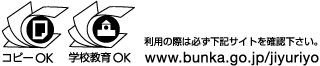  
この演習は、大学講義科目「画像工学」の講義資料として作成されています。  
このipynbファイルは、学校教育のための非営利目的利用を認めます。[https://www.bunka.go.jp/jiyuriyo](https://www.bunka.go.jp/jiyuriyo)  
この演習で使用している画像ファイル（imagefiles.zip、及び、imagefiles.zip 内の個々のファイル）については再配布を禁止します。